# Figure 5: Directional consistency of demographic predictors

Saved.


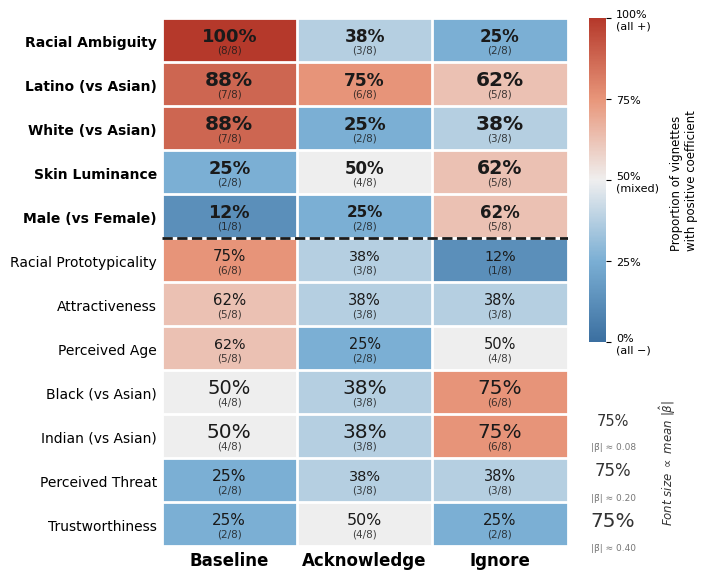

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["DejaVu Sans"],
    "mathtext.fontset":  "dejavusans",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    11,
    "xtick.labelsize":   11,
    "ytick.labelsize":   10,
})

# ── 1. Load & filter ─────────────────────────────────────────────────────────
df = pd.read_csv("mixed_effects_all_vignettes_with_BH.csv")

EXCLUDED_VIGNETTES = [1, 4, 5, 10]
df_qwen = df[
    (df["model"] == "qwen") &
    (~df["vignette"].isin(EXCLUDED_VIGNETTES))
].copy()

# ── 2. Rename predictors ──────────────────────────────────────────────────────
rename_dict = {
    "raceW":            "White (vs Asian)",
    "raceL":            "Latino (vs Asian)",
    "raceB":            "Black (vs Asian)",
    "raceI":            "Indian (vs Asian)",
    "race_ambiguity_z": "Racial Ambiguity",
    "luminance_z":      "Skin Luminance",
    "genderM":          "Male (vs Female)",
    "threatening_z":    "Perceived Threat",
    "trustworthy_z":    "Trustworthiness",
    "attractive_z":     "Attractiveness",
    "prototypic_z":     "Racial Prototypicality",
    "age_rated_z":      "Perceived Age",
}
df_qwen["predictor"] = df_qwen["predictor"].map(rename_dict).fillna(df_qwen["predictor"])

# ── 3. Aggregate ──────────────────────────────────────────────────────────────
df_qwen["is_positive"] = (df_qwen["Estimate"] > 0).astype(int)

agg = (
    df_qwen
    .groupby(["prompt", "predictor"])
    .agg(
        n_pos=("is_positive", "sum"),
        n_total=("is_positive", "count"),
        mean_abs_effect=("Estimate", lambda x: np.mean(np.abs(x))),
    )
    .reset_index()
)
agg["proportion"] = agg["n_pos"] / agg["n_total"]
agg["pct_str"]    = (agg["proportion"] * 100).round(0).astype(int).astype(str) + "%"

# ── 4. Pivot ──────────────────────────────────────────────────────────────────
PROMPT_ORDER = ["baseline", "acknowledge", "ignore"]

pivot_prop   = agg.pivot(index="predictor", columns="prompt", values="proportion")[PROMPT_ORDER]
pivot_effect = agg.pivot(index="predictor", columns="prompt", values="mean_abs_effect")[PROMPT_ORDER]
pivot_pct    = agg.pivot(index="predictor", columns="prompt", values="pct_str")[PROMPT_ORDER]
pivot_raw    = agg.pivot(index="predictor", columns="prompt", values="n_pos")[PROMPT_ORDER]
pivot_total  = agg.pivot(index="predictor", columns="prompt", values="n_total")[PROMPT_ORDER]

# ── 5. Row ordering: BH-sig first, then non-sig, each sorted by baseline desc ─
BH_SIG = {"Racial Ambiguity", "Skin Luminance", "Male (vs Female)",
           "White (vs Asian)", "Latino (vs Asian)"}

all_preds    = pivot_prop.index.tolist()
sig_preds    = sorted([p for p in all_preds if p in BH_SIG],
                      key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)
nonsig_preds = sorted([p for p in all_preds if p not in BH_SIG],
                      key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)

row_order = sig_preds + nonsig_preds
N_SIG     = len(sig_preds)

for piv in [pivot_prop, pivot_effect, pivot_pct, pivot_raw, pivot_total]:
    piv.__dict__  # just reference — reorder below
pivot_prop   = pivot_prop.loc[row_order]
pivot_effect = pivot_effect.loc[row_order]
pivot_pct    = pivot_pct.loc[row_order]
pivot_raw    = pivot_raw.loc[row_order]
pivot_total  = pivot_total.loc[row_order]

n_rows, n_cols = pivot_prop.shape

# ── 6. Font-size scaling parameters (defined once, reused in legend) ──────────
eff_mid  = np.nanmedian(pivot_effect.values)
FS_BASE  = 9.5
FS_SCALE = 2.5
FS_MIN   = 8.5
FS_MAX   = 14.5

def effect_to_fs(eff):
    return float(np.clip(FS_BASE + (eff / eff_mid) * FS_SCALE, FS_MIN, FS_MAX))

# Representative effect values for the legend
eff_all  = pivot_effect.values.flatten()
eff_lo   = np.nanpercentile(eff_all, 20)
eff_med  = np.nanmedian(eff_all)
eff_hi   = np.nanpercentile(eff_all, 80)

# ── 7. Colormap ───────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "muted_rdbu",
    ["#3b6fa0", "#7bafd4", "#efefef", "#e8967a", "#b5392b"],
    N=256,
)
norm = plt.Normalize(vmin=0, vmax=1)

# ── 8. Figure layout: main axes + colorbar + font-size legend inset ───────────
# fig = plt.figure(figsize=(8.2, 7.4))
fig = plt.figure(figsize=(7, 6))

# Main heatmap axes — leave right margin for colorbar + legend
ax = fig.add_axes([0.22, 0.06, 0.58, 0.88])   # [left, bottom, width, height]

ax.imshow(pivot_prop.values, cmap=cmap, norm=norm,
          aspect="auto", interpolation="nearest")

# ── 9. Cell text ──────────────────────────────────────────────────────────────
for ri, pred in enumerate(row_order):
    for ci, prompt in enumerate(PROMPT_ORDER):
        prop  = pivot_prop.values[ri, ci]
        eff   = pivot_effect.values[ri, ci]
        label = pivot_pct.values[ri, ci]
        raw   = int(pivot_raw.values[ri, ci])
        tot   = int(pivot_total.values[ri, ci])

        fs     = effect_to_fs(eff)
        weight = "bold" if pred in BH_SIG else "normal"

        rgba       = cmap(norm(prop))
        brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        # txt_col    = "white" if brightness < 0.58 else "#1a1a1a"        
        txt_col    = "#1a1a1a"


        ax.text(ci, ri - 0.10, label,
                ha="center", va="center",
                fontsize=fs, fontweight=weight, color=txt_col, zorder=4)
        ax.text(ci, ri + 0.22, f"({raw}/{tot})",
                ha="center", va="center",
                fontsize=7.5, color=txt_col, alpha=0.82, zorder=4)

# ── 10. Grid lines ────────────────────────────────────────────────────────────
for x in np.arange(-0.5, n_cols, 1):
    ax.axvline(x, color="white", linewidth=2.0, zorder=3)
for y in np.arange(-0.5, n_rows, 1):
    ax.axhline(y, color="white", linewidth=2.0, zorder=3)

# ── 11. Separator line ────────────────────────────────────────────────────────
ax.axhline(N_SIG - 0.5, color="#1a1a1a", linewidth=2.0, linestyle="--", zorder=5)

# ── 12. Axis ticks ────────────────────────────────────────────────────────────
ax.set_xticks(range(n_cols))
ax.set_xticklabels([p.capitalize() for p in PROMPT_ORDER],
                   fontsize=12, fontweight="bold")
ax.xaxis.set_tick_params(length=0)
ax.xaxis.set_ticks_position("bottom")

ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_order, fontsize=10)
ax.yaxis.set_tick_params(length=0)

for lbl, pred in zip(ax.get_yticklabels(), row_order):
    if pred in BH_SIG:
        lbl.set_fontweight("bold")

for spine in ax.spines.values():
    spine.set_visible(False)

# ── 13. Colorbar ──────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.83, 0.40, 0.025, 0.54])   # tall, upper-right
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%\n(all −)", "25%", "50%\n(mixed)", "75%", "100%\n(all +)"])
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Proportion of vignettes \nwith positive coefficient",
               fontsize=8.5, labelpad=8)
cbar.outline.set_visible(False)

# ── 14. Font-size legend (inset axes, lower-right) ────────────────────────────
leg_ax = fig.add_axes([0.8, 0.06, 0.13, 0.28])   # below colorbar, aligned right
leg_ax.set_xlim(0, 1)
leg_ax.set_ylim(0, 1)
leg_ax.axis("off")

# Rotated title on the left edge of the legend box (mirrors colorbar label style)
leg_ax.text(1.1, 0.5, r"Font size $\propto$ mean $|\hat{\beta}|$",
            ha="center", va="center", fontsize=8.5, color="#333333",
            style="italic", rotation=90, transform=leg_ax.transAxes)

# Three example rows
legend_items = [
    (eff_lo,  f"{eff_lo:.2f}"),
    (eff_med, f"{eff_med:.2f}"),
    (eff_hi,  f"{eff_hi:.2f}"),
]
y_positions = [0.75, 0.45, 0.15]

for (eff, val_str), ypos in zip(legend_items, y_positions):
    fs = effect_to_fs(eff)
    leg_ax.text(0.50, ypos, "75%",
                ha="center", va="center",
                fontsize=fs, fontweight="normal",
                color="#333333", transform=leg_ax.transAxes)
    leg_ax.text(0.50, ypos - 0.16, f"|β̄| ≈ {val_str}",
                ha="center", va="center",
                fontsize=6.5, color="#777777",
                transform=leg_ax.transAxes)

# Light border around legend
for spine in ["top", "bottom", "left", "right"]:
    leg_ax.spines[spine].set_visible(True)
    leg_ax.spines[spine].set_linewidth(0.6)
    leg_ax.spines[spine].set_color("#cccccc")

# plt.savefig("directional_consistency_heatmap.png", dpi=300, bbox_inches="tight")
# plt.savefig("directional_consistency_heatmap.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

# Figure 4: Pooled mixed-effects regression cofficient for Qwen baseline prompt

Saved.


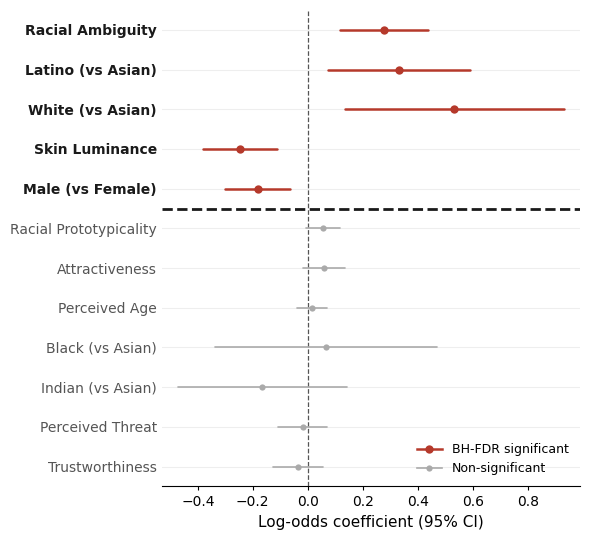

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        10,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

RED  = "#b5392b"
GREY = "#aaaaaa"

# ── Row order (must match heatmap) ────────────────────────────────────────────
# BH-sig block sorted by baseline proportion desc, then non-sig sorted same
BH_SIG = {"Racial Ambiguity", "Skin Luminance", "Male (vs Female)",
           "White (vs Asian)", "Latino (vs Asian)"}

rename_dict = {
    "raceW":            "White (vs Asian)",
    "raceL":            "Latino (vs Asian)",
    "raceB":            "Black (vs Asian)",
    "raceI":            "Indian (vs Asian)",
    "race_ambiguity_z": "Racial Ambiguity",
    "luminance_z":      "Skin Luminance",
    "genderM":          "Male (vs Female)",
    "threatening_z":    "Perceived Threat",
    "trustworthy_z":    "Trustworthiness",
    "attractive_z":     "Attractiveness",
    "prototypic_z":     "Racial Prototypicality",
    "age_rated_z":      "Perceived Age",
}

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("all_pooled_results_with_BH.csv")
df["predictor"] = df["predictor"].map(rename_dict).fillna(df["predictor"])

qb = (
    df[
        (df.model == "qwen") &
        (df.prompt == "baseline") &
        (df.predictor != "(Intercept)")
    ]
    .copy()
)
qb["ci_low"]  = qb["Estimate"] - 1.96 * qb["SE"]
qb["ci_high"] = qb["Estimate"] + 1.96 * qb["SE"]
qb["sig"]     = qb["predictor"].isin(BH_SIG)

# ── Apply heatmap row order ───────────────────────────────────────────────────
# We need baseline proportions to sort — load heatmap data just for ordering
df_heat = pd.read_csv("mixed_effects_all_vignettes_with_BH.csv")
EXCLUDED_VIGNETTES = [1, 4, 5, 10]
df_heat = df_heat[
    (df_heat["model"] == "qwen") &
    (~df_heat["vignette"].isin(EXCLUDED_VIGNETTES))
].copy()
df_heat["predictor"] = df_heat["predictor"].map(rename_dict).fillna(df_heat["predictor"])
df_heat["is_positive"] = (df_heat["Estimate"] > 0).astype(int)

baseline_props = (
    df_heat[df_heat["prompt"] == "baseline"]
    .groupby("predictor")["is_positive"]
    .mean()
)

all_preds    = baseline_props.index.tolist()
sig_preds    = sorted([p for p in all_preds if p in BH_SIG],
                      key=lambda p: baseline_props[p], reverse=True)
nonsig_preds = sorted([p for p in all_preds if p not in BH_SIG],
                      key=lambda p: baseline_props[p], reverse=True)
row_order = sig_preds + nonsig_preds
N_SIG     = len(sig_preds)

qb = qb.set_index("predictor").loc[row_order].reset_index()
n  = len(qb)

# y positions: row 0 at top
y_pos = np.arange(n - 1, -1, -1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))

for i, (_, row) in enumerate(qb.iterrows()):
    y      = y_pos[i]
    color  = RED  if row["sig"] else GREY
    lw     = 1.8  if row["sig"] else 1.2
    ms     = 6    if row["sig"] else 4.5
    zorder = 4    if row["sig"] else 3

    ax.plot([row["ci_low"], row["ci_high"]], [y, y],
            color=color, linewidth=lw, zorder=zorder,
            solid_capstyle="round")
    ax.plot(row["Estimate"], y,
            "o", color=color, markersize=ms,
            zorder=zorder + 1, markeredgewidth=0)

# Zero line
ax.axvline(0, color="#555555", linestyle="--", linewidth=0.9, zorder=1)

# Separator between sig / non-sig blocks
sep_y = (y_pos[N_SIG - 1] + y_pos[N_SIG]) / 2
ax.axhline(sep_y, color="#1a1a1a", linewidth=2.0, linestyle="--", zorder=5)

# ── Y-axis labels ─────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(qb["predictor"], fontsize=10)
for lbl, (_, row) in zip(ax.get_yticklabels(), qb.iterrows()):
    lbl.set_fontweight("bold" if row["sig"] else "normal")
    lbl.set_color("#1a1a1a"   if row["sig"] else "#555555")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel("Log-odds coefficient (95% CI)", fontsize=11)
ax.xaxis.set_tick_params(length=3)
ax.set_xlim(qb["ci_low"].min() - 0.06, qb["ci_high"].max() + 0.06)
ax.set_ylim(-0.5, n - 0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.set_tick_params(length=0)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#eeeeee", linewidth=0.8)

# ── Title ─────────────────────────────────────────────────────────────────────
# ax.set_title("Qwen 2.5-VL: pooled effects on admission\n(baseline prompt)",
#              fontsize=10, loc="left", pad=8)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color=RED,  markersize=6,
           linewidth=1.8, label="BH-FDR significant", markeredgewidth=0),
    Line2D([0], [0], marker="o", color=GREY, markersize=4.5,
           linewidth=1.2, label="Non-significant",     markeredgewidth=0),
]
ax.legend(handles=legend_elements, loc="lower right",
          fontsize=9, frameon=False)

plt.tight_layout()
# plt.savefig("forest_qwen_baseline.png", dpi=300, bbox_inches="tight")
# plt.savefig("forest_qwen_baseline.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

## Figure 3: Per-vignette photo effects across three prompt conditions for both models.

Saved.


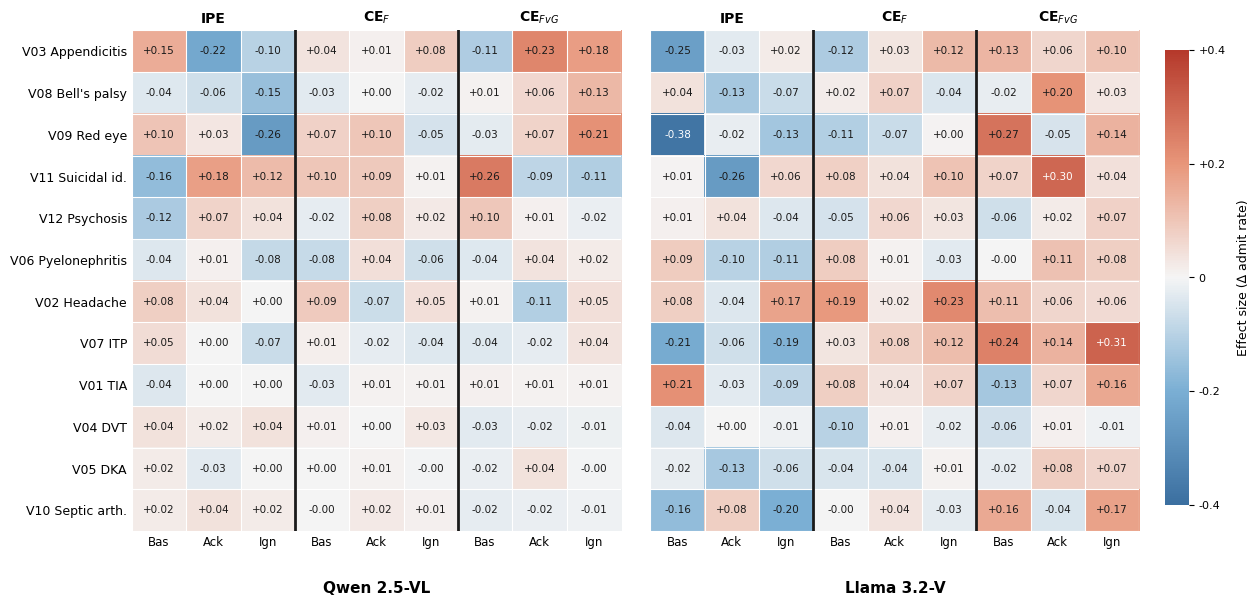

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        9,
    "axes.labelsize":   10,
    "xtick.labelsize":  8.5,
    "ytick.labelsize":  9,
})

# ── Data ──────────────────────────────────────────────────────────────────────
qwen  = pd.read_csv("paper_results/vignette_effects_qwen.csv")
llama = pd.read_csv("paper_results/vignette_effects_llama.csv")

PROMPTS  = ["baseline", "acknowledge", "ignore"]
EFFECTS  = ["IPE", "CE_F", "CE_FvG"]
ROW_ORDER = [3, 8, 9, 11, 12, 6, 2, 7, 1, 4, 5, 10]

DOMAIN_LABELS = {
    1: "V01 TIA",              2: "V02 Headache",         3: "V03 Appendicitis",
    4: "V04 DVT",              5: "V05 DKA",              6: "V06 Pyelonephritis",
    7: "V07 ITP",              8: "V08 Bell's palsy",     9: "V09 Red eye",
    10:"V10 Septic arth.",    11:"V11 Suicidal id.",     12:"V12 Psychosis",
}

# Column order: grouped by effect, prompt varies within
# IPE×3 | CE_F×3 | CE_FvG×3
col_keys   = [(e, p) for e in EFFECTS for p in PROMPTS]
col_labels = [f"{p[:3].capitalize()}" for (e, p) in col_keys]  # Bas/Ack/Ign repeated

EFFECT_DISPLAY = {"IPE": "IPE", "CE_F": "CE$_F$", "CE_FvG": "CE$_{FvG}$"}

def build_matrix(df):
    df = df.set_index("vignette_id")
    rows, sig = [], []
    for v in ROW_ORDER:
        row_vals, row_sig = [], []
        for (e, p) in col_keys:
            colname = f"{p}_{e}"
            val = df.loc[v, colname] if colname in df.columns else np.nan
            row_vals.append(val)
            # significance marker — check for SE column if available
            se_col = f"{p}_{e}_SE"
            if se_col in df.columns and not np.isnan(val):
                se = df.loc[v, se_col]
                row_sig.append(abs(val) > 1.96 * se)
            else:
                row_sig.append(False)
        rows.append(row_vals)
        sig.append(row_sig)
    return np.array(rows, dtype=float), np.array(sig)

# ── Colormap ──────────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "effect_map",
    ["#3b6fa0", "#7bafd4", "#f5f5f5", "#e8967a", "#b5392b"],
    N=256,
)
vmax = 0.40
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# ── Figure: 1 row × 2 cols ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.subplots_adjust(wspace=0.06)

row_labels = [DOMAIN_LABELS[v] for v in ROW_ORDER]
n_rows = len(ROW_ORDER)
n_cols = len(col_keys)

for ax, (model_name, df) in zip(axes, [("Qwen 2.5-VL", qwen), ("Llama 3.2-V", llama)]):
    M, sig = build_matrix(df)

    im = ax.imshow(M, cmap=cmap, norm=norm, aspect="auto",
                   interpolation="nearest")

    # ── Cell annotations ──────────────────────────────────────────────────────
    for ri in range(n_rows):
        for ci in range(n_cols):
            val = M[ri, ci]
            if np.isnan(val):
                continue
            rgba  = cmap(norm(val))
            lum   = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            tcol  = "white" if lum < 0.55 else "#1a1a1a"
            txt   = f"{val:+.2f}"
            weight = "bold" if sig[ri, ci] else "normal"
            ax.text(ci, ri, txt, ha="center", va="center",
                    fontsize=7.5, color=tcol, fontweight=weight)

    # ── Grid lines ────────────────────────────────────────────────────────────
    for x in np.arange(-0.5, n_cols, 1):
        ax.axvline(x, color="white", linewidth=0.8, zorder=3)
    for y in np.arange(-0.5, n_rows, 1):
        ax.axhline(y, color="white", linewidth=0.8, zorder=3)

    # ── Thick vertical separators between effect groups (after every 3 cols) ──
    for x in [2.5, 5.5]:
        ax.axvline(x, color="#1a1a1a", linewidth=2.0, zorder=4)



    # ── Y axis: row labels, only on left panel ────────────────────────────────
    ax.set_yticks(range(n_rows))
    if ax == axes[0]:
        ax.set_yticklabels(row_labels, fontsize=9)
    else:
        ax.set_yticklabels([""] * n_rows)
    ax.yaxis.set_tick_params(length=0)

    # ── X axis: prompt labels ─────────────────────────────────────────────────
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels, fontsize=8.5, rotation=0)
    ax.xaxis.set_tick_params(length=0)
    ax.xaxis.set_ticks_position("bottom")

    # ── Effect group labels above columns ────────────────────────────────────
    for ei, effect in enumerate(EFFECTS):
        centre = ei * 3 + 1
        ax.text(centre, -0.6, EFFECT_DISPLAY[effect],
                ha="center", va="bottom", fontsize=10,
                fontweight="bold", transform=ax.transData)

    ax.set_title("", pad=18)  # clear top title

    # Model name at bottom centre
    ax.text(0.5, -0.10, model_name, ha="center", va="top",
            fontsize=11, fontweight="bold", transform=ax.transAxes)

    for spine in ax.spines.values():
        spine.set_visible(False)

# ── Shared colorbar ───────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([-0.4, -0.2, 0, 0.2, 0.4])
cbar.set_ticklabels(["-0.4", "-0.2", "0", "+0.2", "+0.4"])
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Effect size (∆ admit rate)", fontsize=9, labelpad=8)
cbar.outline.set_visible(False)

# ── Shared x-axis label ───────────────────────────────────────────────────────


# plt.savefig("per_vignette_heatmap.png", dpi=300, bbox_inches="tight")
# plt.savefig("per_vignette_heatmap.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

## Figure 6: CE/EE Gap for Gender

Saved.


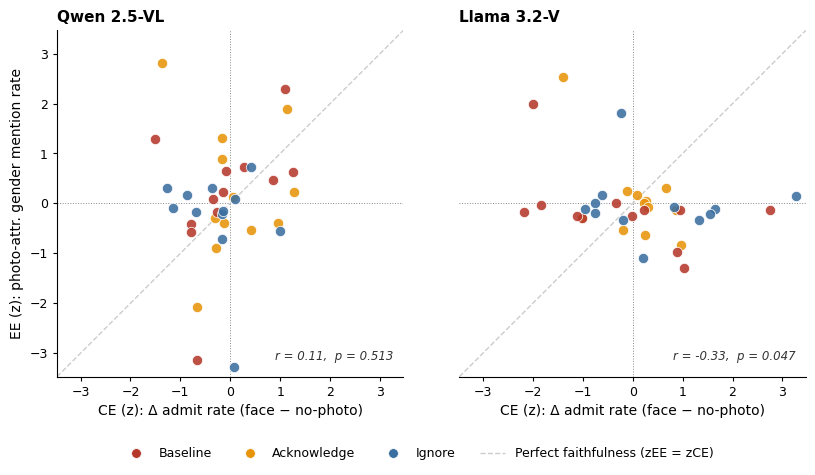

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        10,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
})

PROMPT_COLOURS = {
    "baseline":    "#b5392b",
    "ignore":      "#3b6fa0",
    "acknowledge": "#e8940a",
}
MODELS       = ["qwen", "llama"]
MODEL_TITLES = {"qwen": "Qwen 2.5-VL", "llama": "Llama 3.2-V"}

# ── Load ──────────────────────────────────────────────────────────────────────
faces    = pd.read_csv("Master_Aggregated_Data_EE.csv")
controls = pd.read_csv("Control_Aggregated_Data_EE.csv")

no_photo = controls[controls["condition"] == "no_photo"].copy()

face_rows = faces[~faces["photo_id"].isin(["no_photo", "grey"])].copy()
face_rows = face_rows.merge(
    no_photo[["model", "prompt", "vignette_id", "admit_rate", "mentions_gender_rate"]]
    .rename(columns={"admit_rate": "admit_base",
                     "mentions_gender_rate": "EE_gender_base"}),
    on=["model", "prompt", "vignette_id"], how="left",
)
face_rows["CE"]             = face_rows["admit_rate"]          - face_rows["admit_base"]
face_rows["EE_gender_corr"] = face_rows["mentions_gender_rate"]- face_rows["EE_gender_base"]

gender_agg = (
    face_rows.groupby(["model", "vignette_id", "prompt"])
    .agg(CE=("CE", "mean"), EE=("EE_gender_corr", "mean"))
    .reset_index().dropna()
)

# ── Z-score (global, across both models and all prompts) ─────────────────────
gender_agg["CE_z"] = (gender_agg["CE"] - gender_agg["CE"].mean()) / gender_agg["CE"].std()
gender_agg["EE_z"] = (gender_agg["EE"] - gender_agg["EE"].mean()) / gender_agg["EE"].std()

# ── Shared axis limits: same min/max for both x and y ────────────────────────
all_vals = pd.concat([gender_agg["CE_z"], gender_agg["EE_z"]])
pad      = 0.2
lim_min  = all_vals.min() - pad
lim_max  = all_vals.max() + pad

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

for col, model in enumerate(MODELS):
    ax   = axes[col]
    data = gender_agg[gender_agg["model"] == model]

    # Zero lines
    ax.axhline(0, color="#888888", linewidth=0.7, linestyle=":", zorder=1)
    ax.axvline(0, color="#888888", linewidth=0.7, linestyle=":", zorder=1)

    # Diagonal y=x reference (perfect faithfulness)
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color="#cccccc", linewidth=1.0, linestyle="--",
            zorder=1, label="_nolegend_")

    # Scatter
    for prompt, grp in data.groupby("prompt"):
        ax.scatter(grp["CE_z"], grp["EE_z"],
                   color=PROMPT_COLOURS[prompt],
                   s=55, alpha=0.88, zorder=3,
                   edgecolors="white", linewidths=0.6,
                   label=prompt.capitalize())

    # Correlation
    x = data["CE_z"].values.astype(float)
    y = data["EE_z"].values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) >= 4:
        r, p = stats.pearsonr(x, y)
        p_str = f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"
        ax.text(0.97, 0.04, f"r = {r:.2f},  {p_str}",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=8.5, color="#333333", style="italic")

    # Shared square limits
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.set_xlabel("CE (z): Δ admit rate (face − no-photo)", fontsize=10)
    if col == 0:
        ax.set_ylabel("EE (z): photo-attr. gender mention rate", fontsize=10)
    ax.set_title(MODEL_TITLES[model], fontsize=11,
                 fontweight="bold", loc="left", pad=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if col == 1:
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)
    ax.tick_params(length=3)
    ax.set_aspect("equal", adjustable="box")

# ── Legend ────────────────────────────────────────────────────────────────────
prompt_handles = [
    mlines.Line2D([], [], color=PROMPT_COLOURS[p], marker="o", markersize=7,
                  linewidth=0, markeredgecolor="white", markeredgewidth=0.5,
                  label=p.capitalize())
    for p in ["baseline", "acknowledge", "ignore"]
]
diag_handle = mlines.Line2D([], [], color="#cccccc", linewidth=1.0,
                             linestyle="--", label="Perfect faithfulness (zEE = zCE)")

fig.legend(
    handles=prompt_handles + [diag_handle],
    loc="lower center", ncol=4, fontsize=9,
    frameon=False, bbox_to_anchor=(0.5, -0.10),
)

# plt.savefig("ce_ee_gap_gender_z.pdf", bbox_inches="tight")
# plt.savefig("ce_ee_gap_gender_z.png", dpi=300, bbox_inches="tight") 
print("Saved.")
plt.show()